In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

In [4]:
df = pd.read_csv("employee_data.csv")

df.head()

,Employee_ID,Name,Age,Gender,Department,City,Salary,Joining_Date,Experience_Years,Email,Performance_Rating
0,1,Tanvi Singh,22.0,Male,Operations,Gurugram,54256.0,2019-07-26,11,tanvi.singh1@company.com,Excellent
1,2,Vivek Mehta,26.0,Male,Sales,Lucknow,28905.0,2019-01-19,3,vivek.mehta2@company.com,Good
2,3,Rohan Patel,22.0,Other,Sales,Noida,110181.0,2025-11-12,8,rohan.patel3@company.com,Needs Improvement
3,4,Diya Negi,38.0,Male,Data Analytics,Delhi,116506.0,2022-09-28,5,diya.negi4@company.com,Average
4,5,Avni Gupta,42.0,Female,IT,Dehradun,37676.0,2022-01-10,5,avni.gupta5@company.com,Average


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (490, 11)

Columns:
['Employee_ID', 'Name', 'Age', 'Gender', 'Department', 'City', 'Salary', 'Joining_Date', 'Experience_Years', 'Email', 'Performance_Rating']

Data Types:
Employee_ID             int64
Name                      str
Age                   float64
Gender                    str
Department                str
City                      str
Salary                float64
Joining_Date              str
Experience_Years        int64
Email                     str
Performance_Rating        str
dtype: object


In [6]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

df["Salary"] = pd.to_numeric(df["Salary"], errors="coerce")

df["Experience_Years"] = pd.to_numeric(
    df["Experience_Years"],
    errors="coerce"
)

df["Joining_Date"] = pd.to_datetime(
    df["Joining_Date"],
    errors="coerce"
)

print(df.dtypes)

Employee_ID                    int64
Name                             str
Age                          float64
Gender                           str
Department                       str
City                             str
Salary                       float64
Joining_Date          datetime64[us]
Experience_Years               int64
Email                            str
Performance_Rating               str
dtype: object


In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Employee_ID           0
Name                  0
Age                   0
Gender                0
Department            0
City                  0
Salary                0
Joining_Date          0
Experience_Years      0
Email                 0
Performance_Rating    0
dtype: int64


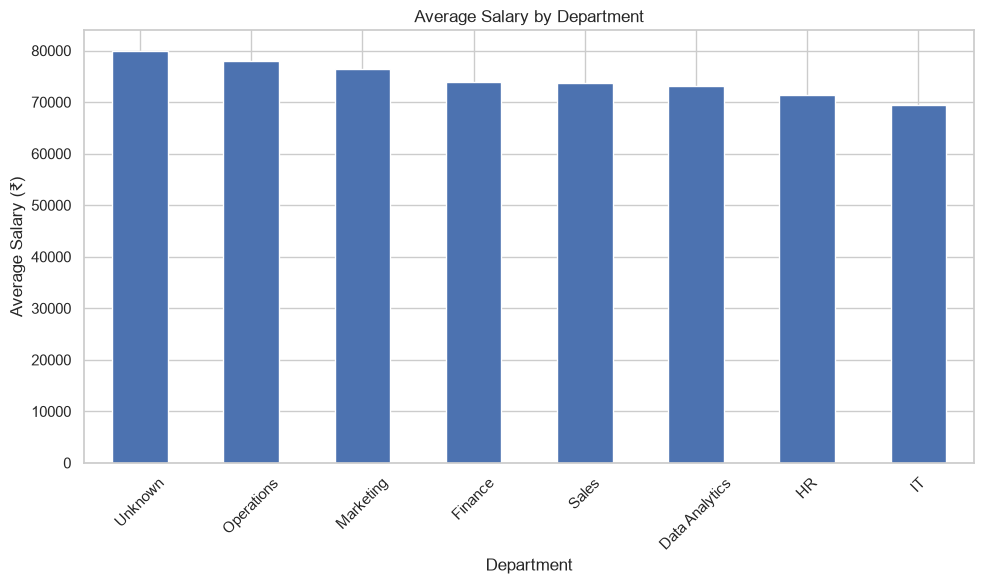

In [8]:
department_salary = (
    df.groupby("Department")["Salary"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

department_salary.plot(
    kind="bar"
)

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

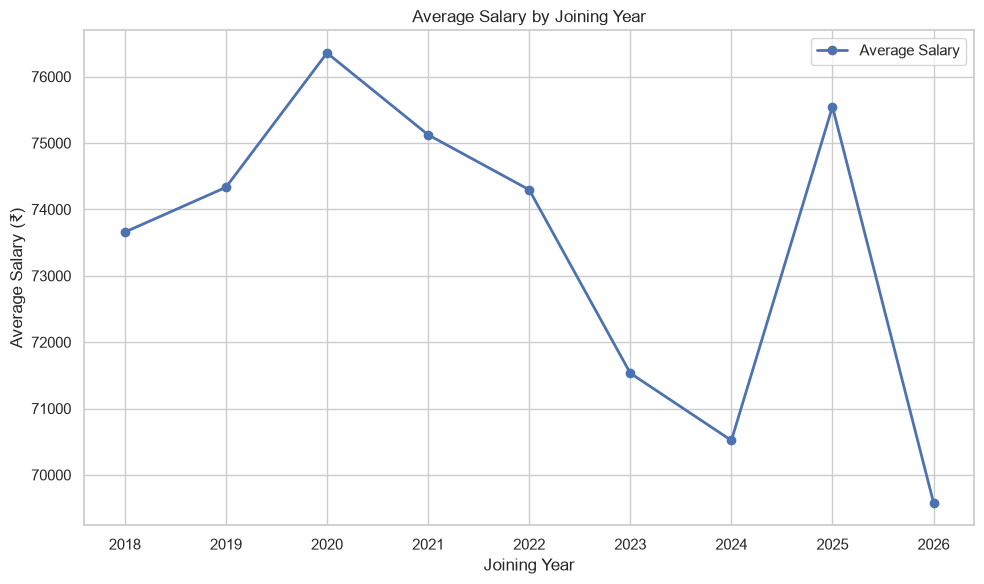

In [9]:
df["Joining_Year"] = df["Joining_Date"].dt.year

yearly_salary = (
    df.groupby("Joining_Year")["Salary"]
    .mean()
)

plt.figure(figsize=(10, 6))

plt.plot(
    yearly_salary.index,
    yearly_salary.values,
    marker="o",
    linewidth=2
)

plt.title("Average Salary by Joining Year")
plt.xlabel("Joining Year")
plt.ylabel("Average Salary (₹)")
plt.legend(["Average Salary"])

plt.grid(True)
plt.tight_layout()

plt.show()

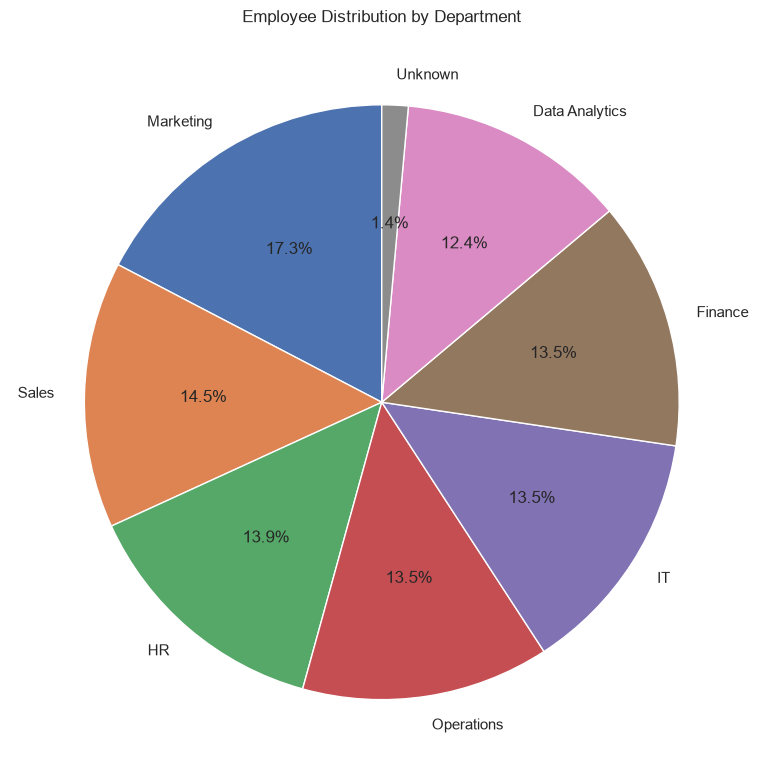

In [10]:
department_count = df["Department"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    department_count.values,
    labels=department_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Employee Distribution by Department")

plt.tight_layout()
plt.show()

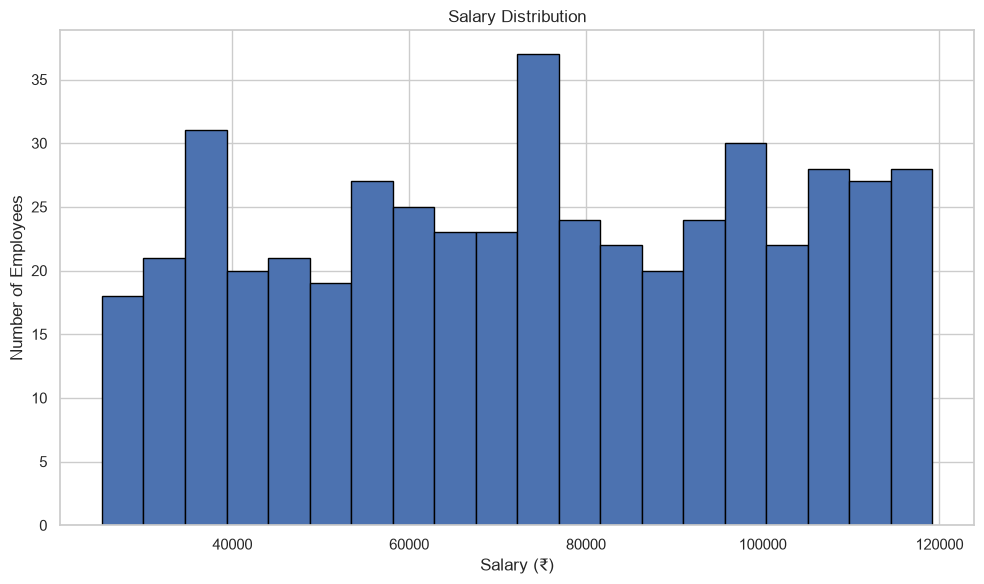

In [11]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Salary"],
    bins=20,
    edgecolor="black"
)

plt.title("Salary Distribution")
plt.xlabel("Salary (₹)")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

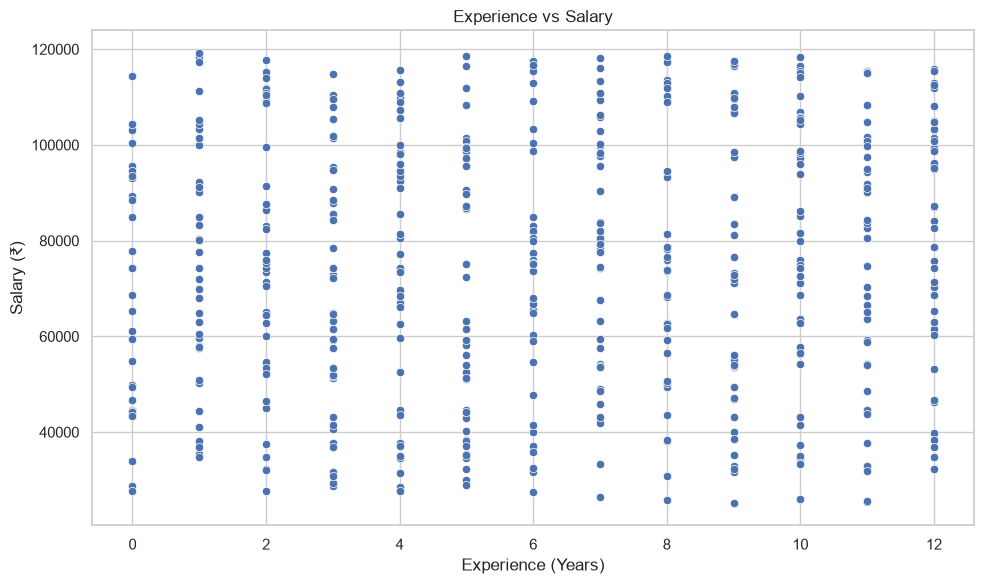

In [12]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Experience_Years",
    y="Salary"
)

plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary (₹)")

plt.tight_layout()
plt.show()

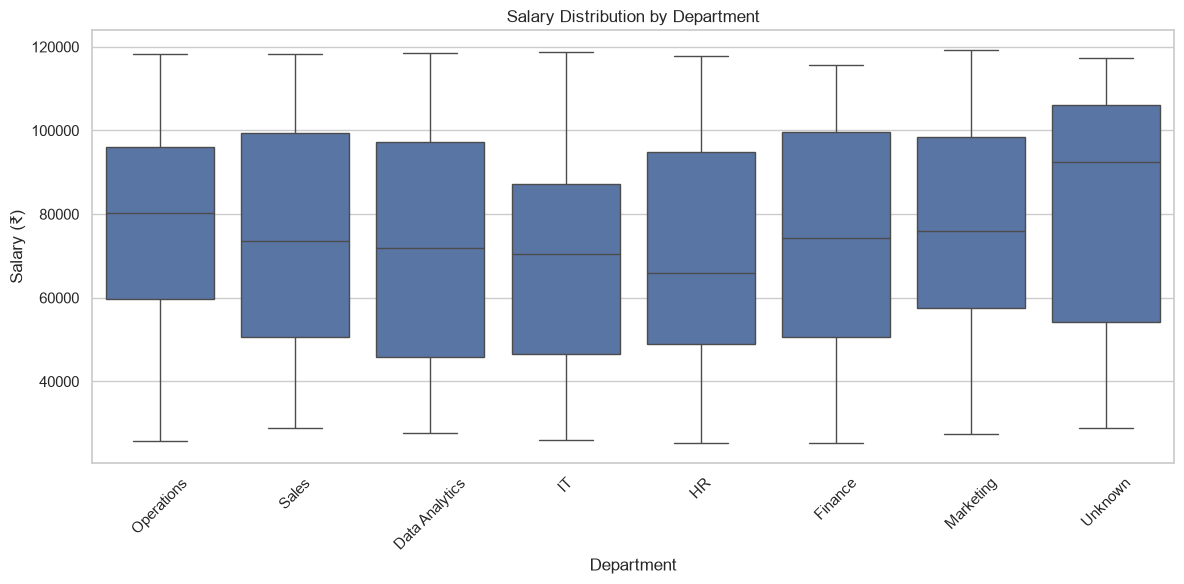

In [13]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Department",
    y="Salary"
)

plt.title("Salary Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Salary (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()